şimdi sms analizi yapıcam hadi bakalım 

In [42]:
import pandas as pd 
import matplotlib.pyplot as plt   #grafik çizme kütüphanemi ekleyeyim 
import warnings                   #Python'ın uyarı sistemini dahil edelim

warnings.filterwarnings('ignore')
# "Gereksiz uyarıları ekrana basma, sessiz çalış" der
# daha önceki kodlarda future warnings vardı onu engellemek için

In [43]:
print("veriyi çekelim")
df = pd.read_csv('cleaned_medical_appointments.csv')  #pandas dataframe nesnesini df ye atalım
# df:dataframe

veriyi çekelim


In [44]:
print(f"Veri boyutu :{df.shape}")   #tablonun kaç satır ve kaç sütun olduğu
df.head()   #tablonun ilk 5 satırını getirsin (jüpiter notebook un out çıktısı)


Veri boyutu :(71959, 14)


,PatientId,Age,Gender,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,wait_days,wait_group,day_of_week
0,9.598513e+13,76,F,REPÚBLICA,0,1,0,0,0,0,No,1,aynı gün,4
1,7.336882e+14,23,F,GOIABEIRAS,0,0,0,0,0,0,Yes,1,aynı gün,4
2,3.449833e+12,39,F,GOIABEIRAS,0,0,0,0,0,0,Yes,1,aynı gün,4
3,7.812456e+13,19,F,CONQUISTA,0,0,0,0,0,0,No,1,aynı gün,4
4,7.345362e+14,30,F,NOVA PALESTINA,0,0,0,0,0,0,No,1,aynı gün,4


gördüğünüz gibi df.head() ın çıktısı gelmedi çünkü son komut o değildi 

print(df.head()) yapabilirdim ama onun yerine sırayı değiştireceğim

not:printf her yerde çalışır

In [45]:
print(f" Temiz veri yüklendi: {df.shape[0]} satır × {df.shape[1]} sütun")

 Temiz veri yüklendi: 71959 satır × 14 sütun


In [46]:
print(" Mevcut sütunlar:")
print(df.columns.tolist())

 Mevcut sütunlar:
['PatientId', 'Age', 'Gender', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show', 'wait_days', 'wait_group', 'day_of_week']


oluşturduğumuz sütunlar hala duruyor güzel

şimdi genel sms etkisini hesaplayalım

Amacımız: "SMS alan hastalar ile almayan hastaların randevuya gelmeme oranlarını karşılaştırmak."

In [47]:
print("1. genel sms etkisi")
# sms durumuna göre no-show oranları hesaplayalım
sms_analysis = df.groupby('SMS_received')['No-show'].value_counts(normalize=True).unstack()

# yes(gelmeyenler) sütununu bul
yes_col = next((c for c in sms_analysis.columns if str(c).lower() == 'yes'), None)

if yes_col:
    general_rates= sms_analysis[yes_col]
    print(f"SMS Almayanlarda Gelmeme Oranı: %{general_rates.get(0, 0)*100:.1f}")
    print(f"SMS Alanlarda Gelmeme Oranı:    %{general_rates.get(1, 0)*100:.1f}")

    fark = general_rates.get(0, 0) - general_rates.get(1, 0)
    print(f" SMS'in Azalttığı Risk: %{fark*100:.1f} puan")
else:
    print("hata var")

1. genel sms etkisi
SMS Almayanlarda Gelmeme Oranı: %29.4
SMS Alanlarda Gelmeme Oranı:    %27.6
 SMS'in Azalttığı Risk: %1.9 puan


df.groupby('SMS_received'):	
Veriyi "SMS alanlar" ve "almayanlar" diye iki gruba ayırır

['No-show'].value_counts(normalize=True):
Her grupta "No" ve "Yes" kaç kez geçmiş, oran (%) olarak hesaplar

.unstack():İç içe olan sonuçları yan yana tabloya çevirir.Dikey listeyi yatay tabloya dönüştür"

next((c for c in ... if str(c).lower() == 'yes'), None):Sütun isimleri arasında 'yes' (büyük/küçük harf fark etmeksizin) arar . "'Yes' sütununu bul, bulamazsan None döndür"

general_rates.get(0, 0):SMS yok grubunun oranını getir

yani SMS göndermek, gelmeme oranını %1.9 puan düşürüyor

Bekleme Grubuna Göre SMS Etkisine bakalım bi de

In [ ]:
print("2. SMS ETKİSİ (Bekleme Süresine Göre):")

# İki değişkene göre grupla: wait_group × SMS_received
detailed = df.groupby(['wait_group', 'SMS_received'])['No-show'].value_counts(normalize=True).unstack()

# Sonuçları okunaklı liste haline getirelim
results = []
for group in ['Aynı Gün', '1-7 Gün', '1-30 Gün', '30+ Gün']:
    if group in detailed.index:
        # SMS almayan (0) ve alan (1) oranlarını çekelim
        no_sms = detailed.loc[group].get(0, pd.Series({yes_col: 0})).get(yes_col, 0) if yes_col else 0
        with_sms = detailed.loc[group].get(1, pd.Series({yes_col: 0})).get(yes_col, 0) if yes_col else 0
        
        results.append({
            'Grup': group,
            'SMS Yok': f"%{no_sms*100:.1f}",
            'SMS Var': f"%{with_sms*100:.1f}",
            'Fark (Puan)': f"{(no_sms - with_sms)*100:.1f}"
        })

# Tabloyu yazdıralım
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

2. SMS ETKİSİ (Bekleme Süresine Göre):
Empty DataFrame
Columns: []
Index: []


groupby(['wait_group', 'SMS_received']):Veriyi iki kriterle gruplar: "30+ gün bekleyen + SMS alan" gibi

detailed.loc[group].get(0, ...):Belirli bir grupta, SMS almayanların (0) oranını güvenli şekilde çeker

results.append({...}):Her grubun sonuçlarını sözlük olarak listeye ekler

pd.DataFrame(results):Listeyi tekrar tabloya çevirir, okunaklı çıktı sağlar



In [49]:
# bi sorun oldu kontrol etcem bi
print(" wait_group sütunundaki BENZERSİZ değerler:")
print(df['wait_group'].unique())
print("\n No-show sütunundaki BENZERSİZ değerler:")
print(df['No-show'].unique())

 wait_group sütunundaki BENZERSİZ değerler:
['aynı gün' '1-7gün' nan '7-30gün' '30+gün']

 No-show sütunundaki BENZERSİZ değerler:
['No' 'Yes']


tamam sorun etiketlerdeymiş hemen halledelim

In [54]:
print("2. SMS ETKİSİ (Bekleme Süresine Göre )(randevusuna gelmeyenler):")

# 1. Boş grupları temizle
df_temp = df.dropna(subset=['wait_group']).copy()

# 2. 'Yes' değerini otomatik bul
yes_val = next((v for v in df_temp['No-show'].unique() if str(v).lower() == 'yes'), None)

if yes_val:
    # 3. YENİ SÜTUN: 1 = Gelmemiş, 0 = Gelmiş
    df_temp['is_no_show'] = (df_temp['No-show'] == yes_val).astype(int)
    
    # 4. Gruplara göre ORTALAMA al
    # İpucu: 0 ve 1'lerin ortalaması, doğrudan "Yüzde Kaç?" demektir!
    sms_rates = df_temp.groupby(['wait_group', 'SMS_received'])['is_no_show'].mean()
    
    # 5. SMS durumunu sütun yap (0 ve 1 yan yana)
    sms_df = sms_rates.unstack(fill_value=0)
    
    # 6. Farkı hesapla
    sms_df['Fark (Puan)'] = sms_df[0] - sms_df[1]
    
    # 7. Okunaklı tabloya çevir
    results = []
    for group in sms_df.index:
        results.append({
            'Grup': group,
            'SMS Yok (%)': f"{sms_df.loc[group, 0]*100:.1f}",
            'SMS Var (%)': f"{sms_df.loc[group, 1]*100:.1f}",
            'Fark (Puan)': f"{sms_df.loc[group, 'Fark (Puan)']*100:.1f}"
        })
    
    results_df = pd.DataFrame(results)
    
    # Mantıksal sıralama
    siralama = ['aynı gün', '1-7gün', '7-30gün', '30+gün']
    results_df['Grup'] = pd.Categorical(results_df['Grup'], categories=siralama, ordered=True)
    print(results_df.sort_values('Grup').to_string(index=False))
else:
    print("'Yes' değeri bulunamadı.")

2. SMS ETKİSİ (Bekleme Süresine Göre )(randevusuna gelmeyenler):
    Grup SMS Yok (%) SMS Var (%) Fark (Puan)
aynı gün        23.8         0.0        23.8
  1-7gün        26.9        24.2         2.6
 7-30gün        36.1        29.2         6.9
  30+gün        37.5        30.3         7.2


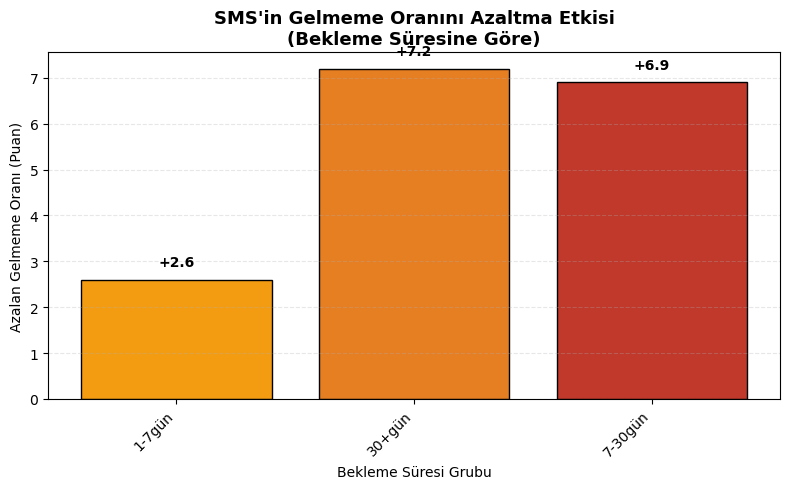

In [ ]:
import matplotlib.pyplot as plt

# Grafik verisini hazırlayalım (aynı gün'ü çıkardım , SMS=0 olduğu için yanıltıcı) sanırım aynı gün randevusu olanlara sms gitmiyor
plot_df = results_df[results_df['Grup'] != 'aynı gün'].copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df['Grup'], plot_df['Fark (Puan)'].astype(float), 
        color=['#f39c12', '#e67e22', '#c0392b'], edgecolor='black')

plt.title('SMS\'in Gelmeme Oranını Azaltma Etkisi\n(Bekleme Süresine Göre)', fontsize=13, fontweight='bold')
plt.xlabel('Bekleme Süresi Grubu')
plt.ylabel('Azalan Gelmeme Oranı (Puan)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Çubukların üzerine değerleri yaz
for i, v in enumerate(plot_df['Fark (Puan)'].astype(float)):
    plt.text(i, v + 0.3, f'+{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()